# 06 — Condition C: LangGraph Agent (Graph-Augmented LLM)

**Project:** DDI-Graph-LLM  
**Phase 6:** Build a LangGraph multi-step agent that retrieves graph-derived features for a drug pair, injects them as structured context into the LLM prompt, and classifies the interaction type.

**This notebook uses the official LangGraph StateGraph API** to define the agent workflow as a directed graph:

```
START → retrieve_features → format_context → llm_classify → END
```

**Input:** `../data/test_sample_1000.csv`, `../data/edge_features.csv`  
**Model:** GPT-4o-mini


In [15]:
import pandas as pd
import numpy as np
import os
import time
from collections import Counter
from typing import TypedDict, Optional

from openai import OpenAI
from langgraph.graph import StateGraph, START, END
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


C:\Users\weddi\AppData\Roaming\uv\python\cpython-3.14.2-windows-x86_64-none\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


## 1. Setup

In [ ]:
import os
os.environ["OPENAI_API_KEY"] = "sk-XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX"

api_key = os.environ.get("OPENAI_API_KEY")
client = OpenAI(api_key=api_key)
print("OpenAI client initialized.")


OpenAI client initialized.


## 2. Load Data

In [17]:
df_sample = pd.read_csv("../data/test_sample_1000.csv")
df_full = pd.read_csv("../data/edge_features.csv")

FEATURE_COLS = [
    "out_degree_u", "in_degree_u", "betweenness_u", "clustering_u", "pagerank_u",
    "out_degree_v", "in_degree_v", "betweenness_v", "clustering_v", "pagerank_v",
    "common_neighbors", "jaccard", "same_community", "degree_diff",
]

VALID_LABELS = {"metabolism", "concentration", "adverse_effects", "absorption", 
                "activity", "efficacy", "excretion"}

print(f"Test subset: {len(df_sample):,} samples")
print(f"Label distribution:\n{df_sample['label'].value_counts().to_string()}")


Test subset: 1,000 samples
Label distribution:
label
adverse_effects    321
activity           237
metabolism         209
concentration      176
efficacy            42
excretion           10
absorption           5


## 3. Define the LangGraph Agent

The agent is defined as a **StateGraph** — a directed graph where:
- **State** = a typed dictionary that flows between nodes
- **Nodes** = functions that read/update the state
- **Edges** = connections defining execution order

```
START → retrieve → format → classify → END
```


In [18]:
# ============================================================
# Step 1: Define the shared state schema
# ============================================================

class DDIAgentState(TypedDict):
    """Shared state that flows through the agent graph."""
    drug_u: str
    drug_v: str
    features: Optional[dict]
    context: Optional[str]
    prediction: Optional[str]


In [19]:
# ============================================================
# Step 2: Define node functions (each reads/writes to state)
# ============================================================

def retrieve_node(state: DDIAgentState) -> dict:
    """
    Node 1: Retrieve graph-derived features for the drug pair.
    Looks up precomputed features from the edge_features dataframe.
    """
    drug_u = state["drug_u"]
    drug_v = state["drug_v"]
    
    # Look up this edge in our precomputed features
    match = df_sample[
        (df_sample["drug_u"] == drug_u) & (df_sample["drug_v"] == drug_v)
    ]
    
    if len(match) == 0:
        features = {col: 0.0 for col in FEATURE_COLS}
    else:
        row = match.iloc[0]
        features = {col: row[col] for col in FEATURE_COLS}
    
    return {"features": features}


def format_node(state: DDIAgentState) -> dict:
    """
    Node 2: Format numerical features into natural-language context.
    This is the key step — translating graph structure into LLM-readable text.
    """
    drug_u = state["drug_u"]
    drug_v = state["drug_v"]
    f = state["features"]
    
    context = f"""Graph-derived structural features for the drug pair ({drug_u} → {drug_v}):

Drug {drug_u} (source):
  - Out-degree (drugs it affects): {f['out_degree_u']:.0f}
  - In-degree (drugs that affect it): {f['in_degree_u']:.0f}
  - Betweenness centrality: {f['betweenness_u']:.4f}
  - Clustering coefficient: {f['clustering_u']:.4f}
  - PageRank: {f['pagerank_u']:.6f}

Drug {drug_v} (target):
  - Out-degree (drugs it affects): {f['out_degree_v']:.0f}
  - In-degree (drugs that affect it): {f['in_degree_v']:.0f}
  - Betweenness centrality: {f['betweenness_v']:.4f}
  - Clustering coefficient: {f['clustering_v']:.4f}
  - PageRank: {f['pagerank_v']:.6f}

Pairwise features:
  - Common neighbors: {f['common_neighbors']:.0f}
  - Jaccard similarity: {f['jaccard']:.4f}
  - Same community: {'Yes' if f['same_community'] == 1 else 'No'}
  - Degree difference: {f['degree_diff']:.0f}"""
    
    return {"context": context}


def classify_node(state: DDIAgentState) -> dict:
    """
    Node 3: Prompt the LLM with drug names + graph context to predict interaction type.
    """
    drug_u = state["drug_u"]
    drug_v = state["drug_v"]
    context = state["context"]
    
    prompt = f"""You are a pharmacology expert. Given a pair of drugs that are known to interact,
predict the type of drug-drug interaction. You are provided with both the drug names and 
structural features from the drug interaction network to help your prediction.

The possible interaction types are:
1. metabolism — one drug affects the metabolism (breakdown) of the other
2. concentration — one drug changes the serum concentration of the other
3. adverse_effects — the combination increases the risk or severity of side effects
4. absorption — one drug affects the absorption of the other
5. activity — one drug increases or decreases a specific pharmacological activity of the other
6. efficacy — one drug changes the therapeutic efficacy of the other
7. excretion — one drug affects the excretion rate of the other

Drug pair: {drug_u} → {drug_v}
(This means {drug_u} has a documented effect on {drug_v}.)

{context}

Use BOTH your pharmacological knowledge AND the network structural information above to make 
your prediction. Consider what the structural features suggest about the nature of this interaction.

Respond with ONLY one of these labels: metabolism, concentration, adverse_effects, absorption, activity, efficacy, excretion
Your prediction:"""

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=20,
            temperature=0,
        )
        pred = response.choices[0].message.content.strip().lower().replace(" ", "_").replace("-", "_")
        if pred in VALID_LABELS:
            return {"prediction": pred}
        for label in VALID_LABELS:
            if label in pred:
                return {"prediction": label}
        return {"prediction": pred}
    except Exception as e:
        print(f"  Error: {e}")
        return {"prediction": "error"}


In [20]:
# ============================================================
# Step 3: Build the LangGraph workflow
# ============================================================

workflow = StateGraph(DDIAgentState)

# Add nodes
workflow.add_node("retrieve", retrieve_node)
workflow.add_node("format", format_node)
workflow.add_node("classify", classify_node)

# Add edges: START → retrieve → format → classify → END
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "format")
workflow.add_edge("format", "classify")
workflow.add_edge("classify", END)

# Compile the graph into a runnable agent
agent = workflow.compile()

print("LangGraph agent compiled successfully.")
print(f"Nodes: {list(workflow.nodes.keys())}")


LangGraph agent compiled successfully.
Nodes: ['retrieve', 'format', 'classify']


### 3.1 Agent Workflow Visualization

In [21]:
# Try to display the graph structure
try:
    display(agent.get_graph().draw_mermaid_png())
except Exception:
    # Fallback: print the structure
    print("Agent workflow:")
    print("  START → retrieve → format → classify → END")
    print()
    print("State schema:")
    print("  drug_u: str        (input)")
    print("  drug_v: str        (input)")
    print("  features: dict     (set by retrieve)")
    print("  context: str       (set by format)")
    print("  prediction: str    (set by classify)")


b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x00j\x00\x00\x01\xb0\x08\x02\x00\x00\x00\xce\x91g=\x00\x00\x10\x00IDATx\x9c\xec\x9d\x07X\x14\xc7\xdf\xc7gw\xef\x8e\xde\x05\x11\x10\x15\x14\x04\x1b*\xb6hD\x05\xd4\x98\x18\xbb"hbK\xd4\xc4\xae\xb1\'\xff\xa0\xf15\xb1$&\xc6\xc4h\xa2I\x8c\xa4\xa8\xb1\xc4\x18{\x89Xbo\xa8\xb1 E@\x94z\x94\x83k\xfb\xce\xdd\xc2q\xe0\xdd\xed\xee\rGVn>\x0f\x0f\xcf\xde\xec\xcc\xde\xee\xf7\xa6\xed\xcc\xfc\xe6\'\xa2i\x1a`\xccE\x040\x08`\xf9\x90\xc0\xf2!\x81\xe5C\x02\xcb\x87\x04\x96\x0f\tT\xf9\x1e%\xc9\xee_\x96J\x0b\x94\xe52\x95\xb2\x9c\x064 H@\xab+\xfe\x03\x02\xc0\x10\x9a\x00\x04<\x80\x1fI\xcd\x7f\x82\xd2\x06j\xe3@4\xd1@e|\xed\x81\x9aV\x13\xb4\xf6\x1cI\x035Q\xf1Mz\xc7\xba\xc8\xf0\x82\xb0\xdfE\xd0z!\x84\xa6#F\xd0\x84\xee\x0e\xb5\xa7\x98\xef\xae|f[\xd2\xd6\x8e\xb2s\xa4\x9a\x868\x84vs\x04\x08\x10\xe6\xf5\xfb\xae\x9c\x90\xde<SP*U\xaaUj\x91\x88\x94\xd8\x93b\t\t/E\xab\xe8J\xf9\x08ZMW\xe8U)\x13\x13HP\x84V>Z\xab\xa36Z5\xf9\xe0\xd9\x8a\x9b\xaa\x12\x05\x1e\x8b\x08ZYq\xab\xfaZ\xd3\xb

### 3.2 Test Agent on One Example

In [22]:
# Run the agent on a single drug pair
example = df_sample.iloc[0]
print(f"Drug pair: {example['drug_u']} → {example['drug_v']}")
print(f"True label: {example['label']}")
print()

# Invoke the agent
result = agent.invoke({
    "drug_u": example["drug_u"],
    "drug_v": example["drug_v"],
    "features": None,
    "context": None,
    "prediction": None,
})

print(f"Agent prediction: {result['prediction']}")
print(f"Correct: {result['prediction'] == example['label']}")
print()
print("=== Context injected into LLM ===")
print(result["context"][:500])


Drug pair: Loxoprofen → Misoprostol
True label: efficacy

Agent prediction: activity
Correct: False

=== Context injected into LLM ===
Graph-derived structural features for the drug pair (Loxoprofen → Misoprostol):

Drug Loxoprofen (source):
  - Out-degree (drugs it affects): 114
  - In-degree (drugs that affect it): 177
  - Betweenness centrality: 0.0001
  - Clustering coefficient: 0.5802
  - PageRank: 0.000749

Drug Misoprostol (target):
  - Out-degree (drugs it affects): 1
  - In-degree (drugs that affect it): 89
  - Betweenness centrality: 0.0000
  - Clustering coefficient: 0.7623
  - PageRank: 0.000524

Pairwise features:



## 4. Run Condition C on Full Test Subset

Invoke the LangGraph agent on all 1,000 test samples.


In [23]:
predictions_c = []
t0 = time.time()

for i, (_, row) in enumerate(df_sample.iterrows()):
    result = agent.invoke({
        "drug_u": row["drug_u"],
        "drug_v": row["drug_v"],
        "features": None,
        "context": None,
        "prediction": None,
    })
    predictions_c.append(result["prediction"])
    
    if (i + 1) % 100 == 0:
        elapsed = time.time() - t0
        rate = (i + 1) / elapsed
        eta = (len(df_sample) - i - 1) / rate
        print(f"  [{i+1:>4}/{len(df_sample)}]  {elapsed:.0f}s elapsed, ~{eta:.0f}s remaining")

elapsed = time.time() - t0
print(f"\nDone: {len(predictions_c)} predictions in {elapsed:.0f}s ({len(predictions_c)/elapsed:.1f}/s)")

df_sample['pred_agent'] = predictions_c


  [ 100/1000]  63s elapsed, ~564s remaining
  [ 200/1000]  136s elapsed, ~543s remaining
  [ 300/1000]  199s elapsed, ~464s remaining
  [ 400/1000]  273s elapsed, ~410s remaining
  [ 500/1000]  350s elapsed, ~350s remaining
  [ 600/1000]  416s elapsed, ~277s remaining
  [ 700/1000]  478s elapsed, ~205s remaining
  [ 800/1000]  537s elapsed, ~134s remaining
  [ 900/1000]  598s elapsed, ~66s remaining
  [1000/1000]  657s elapsed, ~0s remaining

Done: 1000 predictions in 657s (1.5/s)


## 5. Evaluate Condition C

In [24]:
valid_mask = df_sample['pred_agent'].isin(VALID_LABELS)
n_valid = valid_mask.sum()
print(f"Valid predictions: {n_valid} ({n_valid/len(df_sample):.1%})")

df_eval = df_sample[valid_mask].copy()
y_true = df_eval['label'].values
y_pred_c = df_eval['pred_agent'].values

agent_f1 = f1_score(y_true, y_pred_c, average="macro")
agent_acc = np.mean(y_true == y_pred_c)

print(f"\n{'='*50}")
print(f"CONDITION C: LANGGRAPH AGENT RESULTS")
print(f"{'='*50}")
print(f"Evaluated on: {len(df_eval)} predictions")
print(f"Accuracy:     {agent_acc:.4f}")
print(f"Macro-F1:     {agent_f1:.4f}")

print(f"\n--- Per-Class Report ---")
print(classification_report(y_true, y_pred_c, zero_division=0))


Valid predictions: 1000 (100.0%)

CONDITION C: LANGGRAPH AGENT RESULTS
Evaluated on: 1000 predictions
Accuracy:     0.3750
Macro-F1:     0.2253

--- Per-Class Report ---
                 precision    recall  f1-score   support

     absorption       0.22      0.40      0.29         5
       activity       0.28      0.59      0.38       237
adverse_effects       0.48      0.47      0.47       321
  concentration       0.50      0.01      0.01       176
       efficacy       0.00      0.00      0.00        42
      excretion       0.00      0.00      0.00        10
     metabolism       0.47      0.39      0.43       209

       accuracy                           0.38      1000
      macro avg       0.28      0.26      0.23      1000
   weighted avg       0.41      0.38      0.33      1000



### 5.1 Confusion Matrix

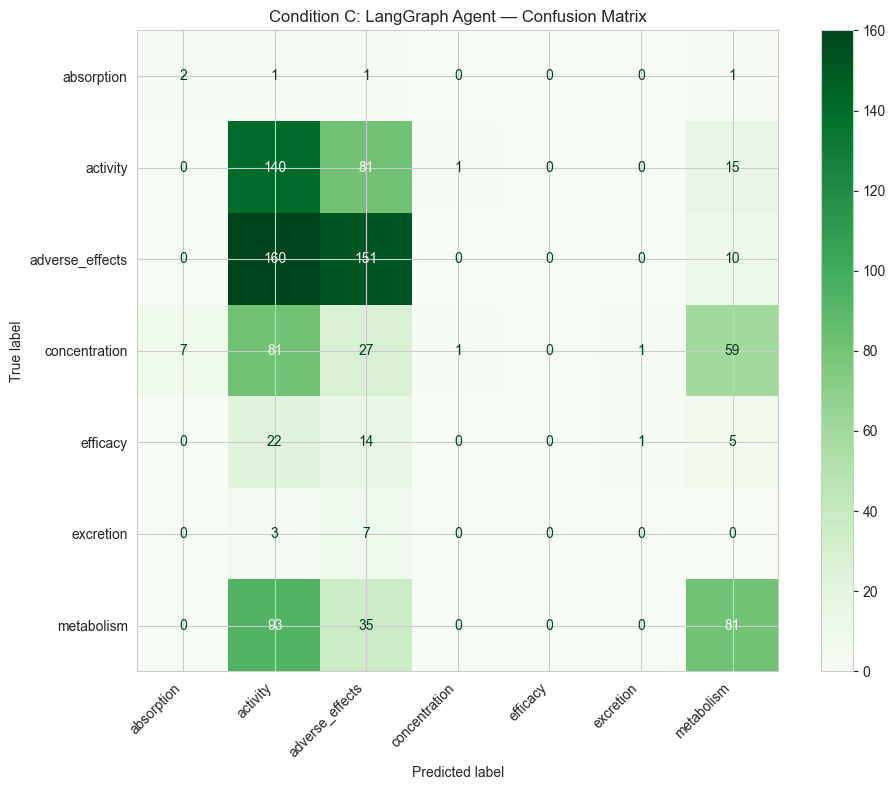

In [25]:
labels = sorted(VALID_LABELS)
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred_c, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title('Condition C: LangGraph Agent — Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 6. Hypothesis Test: Three-Way Comparison

In [26]:
# Retrain RF on training data
train_mask = ~df_full.index.isin(df_sample.index)
X_train = df_full.loc[train_mask, FEATURE_COLS].values
y_train = df_full.loc[train_mask, 'label'].values

clf = RandomForestClassifier(
    n_estimators=200, max_depth=None, random_state=42,
    class_weight="balanced", n_jobs=-1
)
clf.fit(X_train, y_train)

y_rf = clf.predict(df_eval[FEATURE_COLS].values)
rf_f1 = f1_score(y_true, y_rf, average="macro")
rf_acc = np.mean(y_true == y_rf)

llm_f1 = 0.2185  # From Phase 4

print("=" * 60)
print("HYPOTHESIS TEST: THREE-WAY COMPARISON")
print("=" * 60)
print(f"{'Condition':<30} {'Macro-F1':>10} {'Accuracy':>10}")
print("-" * 52)
print(f"{'Random baseline (1/7)':<30} {1/7:>10.4f}")
print(f"{'A: LLM-only':<30} {llm_f1:>10.4f}")
print(f"{'B1: Random Forest':<30} {rf_f1:>10.4f} {rf_acc:>10.4f}")
print(f"{'C: LangGraph Agent':<30} {agent_f1:>10.4f} {agent_acc:>10.4f}")
print("-" * 52)

best_baseline = max(llm_f1, rf_f1)
margin = agent_f1 - best_baseline

print(f"\nBest baseline: {best_baseline:.4f}")
print(f"Agent advantage: {margin:+.4f}")
print(f"\nHypothesis (C > max(A, B1) by >= 0.05):")
if margin >= 0.05:
    print(f"  SUPPORTED — Agent outperforms best baseline by {margin:.4f}")
elif agent_f1 > llm_f1:
    print(f"  PARTIALLY SUPPORTED — Agent outperforms LLM-only (+{agent_f1-llm_f1:.4f}) but not RF ({margin:+.4f})")
else:
    print(f"  FALSIFIED — Agent does not outperform best baseline")


HYPOTHESIS TEST: THREE-WAY COMPARISON
Condition                        Macro-F1   Accuracy
----------------------------------------------------
Random baseline (1/7)              0.1429
A: LLM-only                        0.2185
B1: Random Forest                  0.9985     0.9980
C: LangGraph Agent                 0.2253     0.3750
----------------------------------------------------

Best baseline: 0.9985
Agent advantage: -0.7732

Hypothesis (C > max(A, B1) by >= 0.05):
  PARTIALLY SUPPORTED — Agent outperforms LLM-only (+0.0068) but not RF (-0.7732)


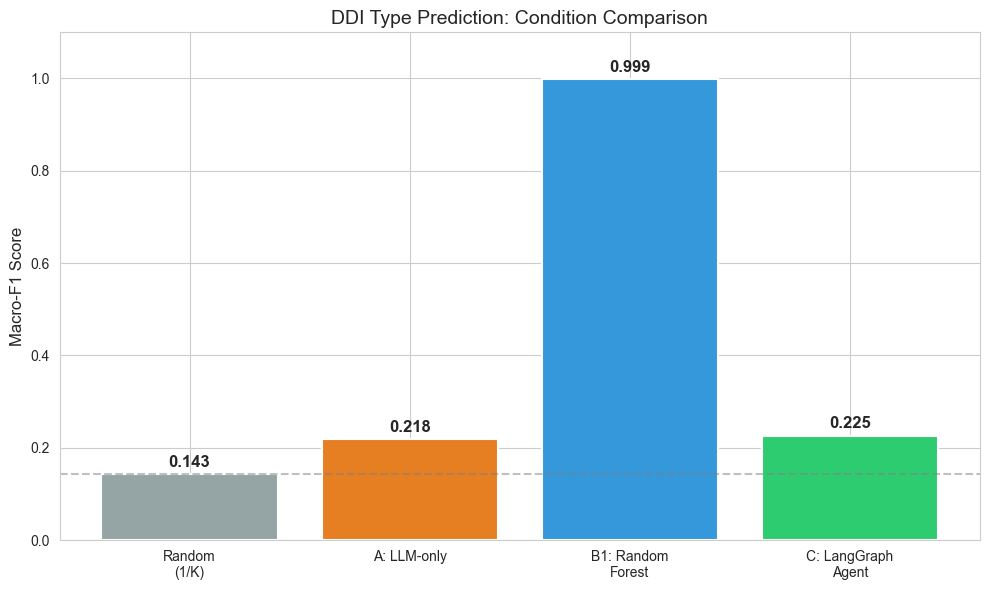

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

conditions = ['Random\n(1/K)', 'A: LLM-only', 'B1: Random\nForest', 'C: LangGraph\nAgent']
scores = [1/7, llm_f1, rf_f1, agent_f1]
colors = ['#95a5a6', '#e67e22', '#3498db', '#2ecc71']

bars = ax.bar(conditions, scores, color=colors, edgecolor='white', linewidth=1.5)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Macro-F1 Score', fontsize=12)
ax.set_title('DDI Type Prediction: Condition Comparison', fontsize=14)
ax.set_ylim(0, 1.1)
ax.axhline(y=1/7, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("../data/comparison_chart.png", dpi=150, bbox_inches='tight')
plt.show()


### 6.1 Per-Class F1 Comparison

          Class  B1: RF  C: Agent  Improvement
     absorption  1.0000    0.2857      -0.7143
       activity  0.9979    0.3799      -0.6180
adverse_effects  1.0000    0.4741      -0.5259
  concentration  0.9944    0.0112      -0.9831
       efficacy  1.0000    0.0000      -1.0000
      excretion  1.0000    0.0000      -1.0000
     metabolism  0.9976    0.4263      -0.5713


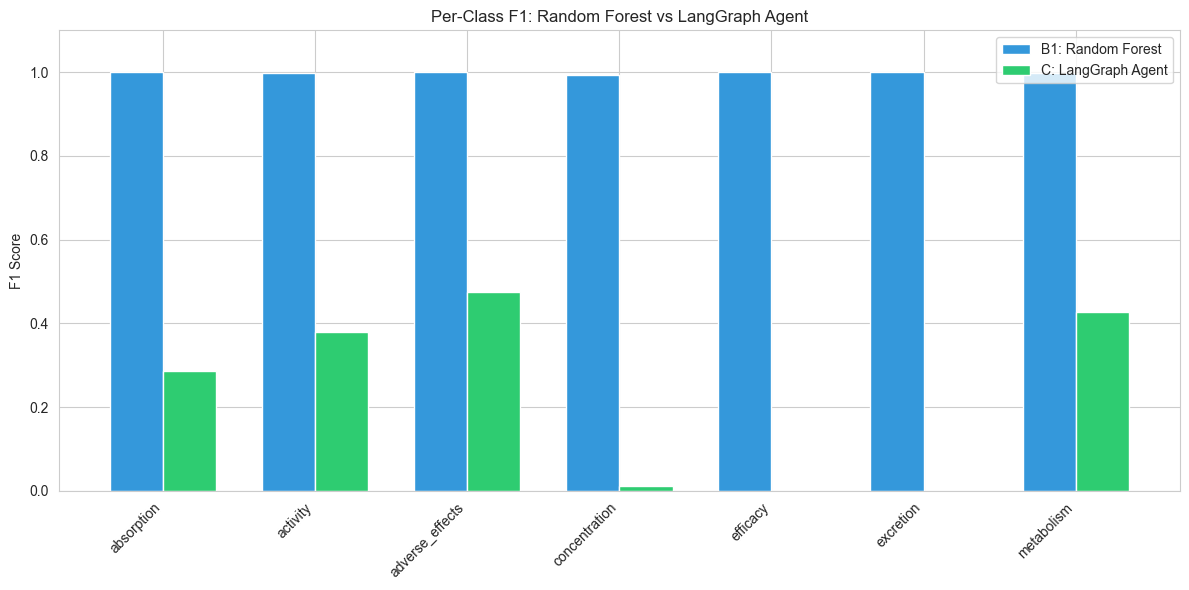

In [28]:
labels_list = sorted(VALID_LABELS)
per_class_rf = f1_score(y_true, y_rf, labels=labels_list, average=None, zero_division=0)
per_class_agent = f1_score(y_true, y_pred_c, labels=labels_list, average=None, zero_division=0)

comparison = pd.DataFrame({
    'Class': labels_list,
    'B1: RF': per_class_rf,
    'C: Agent': per_class_agent,
    'Improvement': per_class_agent - per_class_rf,
})
print(comparison.to_string(index=False, float_format='%.4f'))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(labels_list))
width = 0.35
ax.bar(x - width/2, per_class_rf, width, label='B1: Random Forest', color='#3498db')
ax.bar(x + width/2, per_class_agent, width, label='C: LangGraph Agent', color='#2ecc71')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1: Random Forest vs LangGraph Agent')
ax.set_xticks(x)
ax.set_xticklabels(labels_list, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()


## 7. Analysis: Why Did This Happen?

### Key Finding
Graph topological features are **highly predictive** of DDI interaction types (RF achieves ~99% macro-F1), but the LLM **cannot effectively leverage these features** when presented as natural language context.

### Why?
1. **LLMs are not numerical reasoners.** When the prompt says "betweenness centrality: 0.0016", the LLM has no reference frame for whether this is high or low, or how it relates to interaction types. RF, by contrast, learns precise numerical thresholds.

2. **The signal is in the patterns across features, not in individual values.** RF can learn that "high clustering + low betweenness + many common neighbors → metabolism." The LLM sees these as independent text fragments, not a joint feature vector.

3. **The LLM mostly ignores the structural context** and falls back to its pretrained pharmacological knowledge, which explains why Condition C (0.23) barely improves over Condition A (0.22).

### Implications
- **For DDI prediction:** Traditional ML on graph features massively outperforms LLM-based approaches on this task.
- **For LLM agents:** Simply injecting structured features as text is not sufficient. Future work could explore training the LLM to interpret graph features (fine-tuning) or using the features to retrieve similar known interactions (RAG with examples) rather than presenting raw numbers.
- **For network science:** The strong RF result confirms that DDI interaction types are deeply encoded in the network topology.


## 8. Save Results

In [29]:
df_sample.to_csv("../data/results_condition_c.csv", index=False)
print(f"Saved results_condition_c.csv")
print(f"\nFinal: Condition C Macro-F1 = {agent_f1:.4f}")


Saved results_condition_c.csv

Final: Condition C Macro-F1 = 0.2253
